# 1. Разделите данные на обучение и тест

Используйте `train_test_split(..., test_size=0.8, random_state=241)`.


In [1]:
import pandas as pd 
import numpy as np 
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
import matplotlib.pyplot as plt

data = pd.read_csv('gbm-data.csv')
x= data.drop('Activity', axis=1)
y=data['Activity']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8, random_state=241)


# 2. Обучите Gradient Boosting для разных `learning_rate`

Для каждого значения найдите минимальный `log_loss` на тестовой выборке, номер итерации и постройте графики для train/test.


      Iter       Train Loss   Remaining Time 
         1           1.0190            9.41s
         2           0.9192            8.78s
         3           0.8272            8.38s
         4           0.7834            8.23s
         5           0.7109            8.27s
         6           0.6368            8.25s
         7           0.5797            8.15s
         8           0.5610            8.04s
         9           0.5185            8.03s
        10           0.4984            7.96s
        20           0.1999            7.53s
        30           0.1313            6.99s
        40           0.0790            6.64s
        50           0.0511            6.27s
        60           0.0352            6.02s
        70           0.0245            5.93s
        80           0.0162            5.79s
        90           0.0114            5.56s
       100           0.0077            5.29s
       200           0.0002            1.85s
1: min_log_loss = 0.5822942594278475, iteration = 1
  

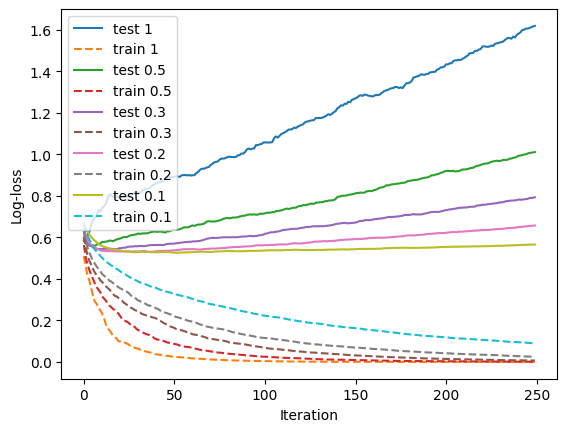

In [2]:
learning_rates = [1, 0.5, 0.3, 0.2, 0.1]
results = {}
plt.figure()
for lr in learning_rates:
    model = GradientBoostingClassifier(n_estimators=250, verbose=True, random_state=241, learning_rate=lr)
    model.fit(x_train, y_train)

    train_loss=[]
    test_loss=[]
    for train_decision, test_decision in zip(model.staged_decision_function(x_train), model.staged_decision_function(x_test)):
        train_probabilities = 1.0 / (1.0 + np.exp(-train_decision))
        test_probabilities = 1.0 / (1.0 + np.exp(-test_decision))
        train_loss.append(log_loss(y_train, train_probabilities))
        test_loss.append(log_loss(y_test, test_probabilities))

    min_loss = min(test_loss)
    best_iteration = test_loss.index(min_loss) + 1
    results[lr] = (min_loss, best_iteration)
    print(f'{lr}: min_log_loss = {min_loss}, iteration = {best_iteration}')
    plt.plot(test_loss, label=f'test {lr}')
    plt.plot(train_loss, '--', label=f'train {lr}')

plt.xlabel('Iteration')
plt.ylabel('Log-loss')
plt.legend()
plt.show()


# 3. Сравните с Random Forest

Возьмите число деревьев, равное лучшей итерации для `learning_rate = 0.2`, и сравните `log_loss`.


In [3]:
best_iteration = results[0.2][1]
print('Overfitting')
print(f'{results[0.2][0]:.2f} {best_iteration}')

random_forest = RandomForestClassifier(n_estimators=best_iteration, random_state=241)
random_forest.fit(x_train, y_train)
rf_probabilities = random_forest.predict_proba(x_test)[:, 1]
rf_log_loss = log_loss(y_test, rf_probabilities)

print(f'{rf_log_loss:.2f}')


Overfitting
0.53 37
0.54
